# Case 3 — Multi-Asset Portfolio Risk & Hedging


## 1. Original Question

### Case 3: Multi-Asset Portfolio Risk & Hedging

**Context:** You manage a \$1B portfolio:

- 50% Long-only equity portfolio (20 stocks - you define composition)
- 50% SRT positions (20 SRTs - selling protection)
- Currently unlevered

**Task:** Design a comprehensive risk management framework.

**Requirements:**

1. Identify common factor risks across both equity and SRT positions
2. Propose specific hedges to neutralize identified common factors
3. Create a portfolio presentation table showing:
   - Long book (equities and SRTs)
   - Proposed hedge book
   - Net exposures
4. Explain your risk measurement approach for this multi-asset portfolio
5. Discuss critical correlation assumptions and stress scenarios

**Deliverables:**

1. Portfolio composition table with the following structure:

   **Net Exposure**

2. Risk measurement framework outline
3. Stress scenario analysis (brief)
4. AI usage summary (if applicable): cross-asset correlation insights, hedging strategy validation, any limitations discovered

*Source: [Risk Analyst Case Study.pdf](Risk%20Analyst%20Case%20Study.pdf), pp. 2–3. The supplied PDF shows only “Net Exposure” in the table-template area; no additional columns are visible.*


## 2. Common Risk Factors

For interpretability, I select four broad systematic risk factors:

1. **Market**
2. **Credit Spread**
3. **Interest Rate**
4. **Volatility**

**Lesson from Case 1.** Case 1 examines factor exposures at the individual-stock level. Moving to portfolio construction requires adapting the factor selection to capture shared risks across assets and strategies. We therefore begin with these four broad factors, prioritizing common explanatory power over a larger set of potentially overlapping factors.

**Lesson from Case 2.** We use observable market factors as proxies for the underlying economic risks discussed in Case 2. A shared economic shock can affect both market observations and credit losses; the mapping below does not impose a one-way causal relationship.

| Observable factor | Underlying risk in Case 2 |
|---|---|
| **Market** | Macro downturn |
| **Credit Spread** | Macro and credit deterioration; sector shocks |
| **Interest Rate** | Interest-rate and refinancing risk |
| **Volatility** | Stress and joint default–recovery deterioration |


## 3. Risk Management Framework (Measurement and Exposure)

I analyze equities and SRTs separately, using return regressions for equities and model-based repricing for SRTs. I express their sensitivities to the four common factors in consistent dollar units, then aggregate them using position sizes. I measure the hedge contributions in the same units and calculate net exposures to assess the remaining common-factor risk after hedging.

| Sleeve | Initial allocation | Exposure estimation |
|---|---|---|
| Long-only equities: 20 stocks | \$500MM | Four-factor regression of equity portfolio returns |
| SRTs: 20 protection-selling positions | \$500MM | Six buckets: tranche seniority × underlying pool credit quality; four betas per bucket |

The \$500MM SRT allocation is portfolio capital allocated to those positions, not the EAD of their reference loan pools. Section 5 specifies the illustrative bucket allocations and tranche boundaries; reference-pool EADs and contractual notionals remain to be specified.

### 3.1 Common factor coordinates

Use the same factor coordinates and units for both sleeves. Equity betas are estimated from daily returns; SRT betas are local valuation sensitivities from a five-year cash-flow model. Applying both to daily factor changes is an illustrative approximation, not a calibration to daily SRT returns:

$$
\mathbf f_t = \left((r_{M,t}-r_{f,t}),\ \Delta s_t,\ \Delta y_t,\ \Delta v_t\right),
\qquad
\boldsymbol\beta_j = (\beta_{j,1},\beta_{j,2},\beta_{j,3},\beta_{j,4}).
$$

Here the factors are broad equity market excess returns, credit-spread changes, benchmark-yield changes and implied-volatility changes. Each beta measures return or normalized-value sensitivity to one factor, holding the others fixed. Fix the proxies and units before estimation so the coefficients can be compared and aggregated.

### 3.2 Equity sleeve

Construct the return series of the 20-stock portfolio using the chosen holdings and rebalancing rule, subtract the daily risk-free return, then estimate:

$$
r_{E,t}-r_{f,t}=\alpha_E+\beta_{E,1}(r_{M,t}-r_{f,t})+\beta_{E,2}\Delta s_t
+\beta_{E,3}\Delta y_t+\beta_{E,4}\Delta v_t+\varepsilon_{E,t}.
$$

This produces one set of four betas for the equity sleeve. Check factor overlap, coefficient stability and residual risk before using the estimates for hedging.

### 3.3 SRT sleeve

Group the SRT sleeve into six buckets by **tranche seniority × underlying loan-pool credit quality**:

| Tranche seniority | Higher-quality pool (H) | Lower-quality pool (L) |
|---|---|---|
| First-loss | $\boldsymbol\beta_{FL,H}$ | $\boldsymbol\beta_{FL,L}$ |
| Mezzanine | $\boldsymbol\beta_{Mezz,H}$ | $\boldsymbol\beta_{Mezz,L}$ |
| Senior | $\boldsymbol\beta_{Sr,H}$ | $\boldsymbol\beta_{Sr,L}$ |

Each bucket has a **1 × 4 beta vector** capturing its exposure to the four common risk factors, in the same order as the equity sleeve:

$$
\boldsymbol\beta_{s,q}
=\left(\beta_{s,q,1},\beta_{s,q,2},\beta_{s,q,3},\beta_{s,q,4}\right)
\quad\text{(Market, Credit Spread, Interest Rate, Volatility).}
$$

This common representation allows the SRT and equity sleeves' systematic risk exposures to be compared and aggregated.

### 3.4 Aggregate the exposures

Using allocation weights $w_{s,q}$ within the SRT sleeve, summing to one:

$$
\boldsymbol\beta_{SRT}
=\sum_{s\in\{FL,Mezz,Sr\}}\sum_{q\in\{H,L\}}w_{s,q}\boldsymbol\beta_{s,q},
\qquad
\boldsymbol\beta_P=0.5\boldsymbol\beta_E+0.5\boldsymbol\beta_{SRT}.
$$


## 4. Equity Portfolio: Four-Factor Regression

Select 20 large US-listed stocks across 11 broad sectors, with **5% per stock** (\$25MM each within the \$500MM equity sleeve). This is an illustrative selection, not optimized using sample returns. Sector labels are broad analytical groupings. The historical exercise uses today's selected basket and is not a point-in-time investment backtest.

<div style="overflow-x:auto; margin:12px 0;"><table style="width:100%; border-collapse:collapse; font-size:11px; line-height:1.5;" cellpadding="7">
<thead><tr style="background:rgba(128,128,128,0.12);"><th>Sector</th><th>Selected Stocks</th><th>Equity Sleeve Weight</th><th>Allocation</th></tr></thead>
<tbody>
<tr><td>Information Technology</td><td>MSFT, NVDA</td><td>10%</td><td>$50MM</td></tr>
<tr><td>Financials</td><td>JPM, BAC</td><td>10%</td><td>$50MM</td></tr>
<tr><td>Health Care</td><td>JNJ, UNH</td><td>10%</td><td>$50MM</td></tr>
<tr><td>Consumer Discretionary</td><td>AMZN, HD</td><td>10%</td><td>$50MM</td></tr>
<tr><td>Consumer Staples</td><td>PG, KO</td><td>10%</td><td>$50MM</td></tr>
<tr><td>Energy</td><td>XOM, CVX</td><td>10%</td><td>$50MM</td></tr>
<tr><td>Industrials</td><td>CAT, HON</td><td>10%</td><td>$50MM</td></tr>
<tr><td>Communication Services</td><td>GOOGL, VZ</td><td>10%</td><td>$50MM</td></tr>
<tr><td>Utilities</td><td>NEE, DUK</td><td>10%</td><td>$50MM</td></tr>
<tr><td>Materials</td><td>LIN</td><td>5%</td><td>$25MM</td></tr>
<tr><td>Real Estate</td><td>PLD</td><td>5%</td><td>$25MM</td></tr>
<tr style="background:rgba(128,128,128,0.09); font-weight:600;"><td>Total</td><td>20 stocks; 5% each</td><td>100%</td><td>$500MM</td></tr>
</tbody></table></div>

Use five years of daily data: **2021-08-31 to 2026-08-31**. Compute daily returns from adjusted prices and take their equal-weight average, assuming daily rebalancing, fractional holdings and no trading costs.

| Common factor | Observable proxy | Regression units |
|---|---|---|
| Market | Fama–French daily `Mkt-RF` | Decimal excess return |
| Credit Spread | Change in [US high-yield OAS, BAMLH0A0HYM2](https://fred.stlouisfed.org/series/BAMLH0A0HYM2) | Basis points |
| Interest Rate | Change in [10-year Treasury yield, DGS10](https://fred.stlouisfed.org/series/DGS10) | Basis points |
| Volatility | Daily change in VIX | Index points |

Regress the equity portfolio's **excess return** (equal-weight total return minus daily French `RF`) on these four factors and an intercept, consistent with Section 3. Use Newey–West HAC standard errors (five lags), as in Case 1. Betas are conditional associations; raw magnitudes across different factor units are not directly comparable.

Prices come from Yahoo Finance. Market excess returns and daily risk-free returns come from the [Kenneth French Data Library](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html); both published percent series are divided by 100. Only `Mkt-RF` and `RF` are used from the downloaded French factor file. Reuse Case 1's download, checksum-validation and isolated-gap helpers. On the equity calendar, carry forward only isolated interior missing yield/spread levels for one session; disclose these imputations. Never fill stock prices or silently drop regression rows. Cached inputs allow offline replay.

**Credit-spread history:** FRED currently exposes only about three years of this series. Earlier observations use a [pinned historical copy of the same FRED series](https://github.com/maaurocp/Trading_Protocol/blob/bf64e83fa4c2a6e72c37d3883476dc81bd9d2e31/data/raw/fred_BAMLH0A0HYM2.csv). All 612 available nonmissing overlapping observations match current FRED values exactly; current FRED values take precedence. The archive and overlap comparison are saved with the input data. Earlier observations are from a third-party archive rather than a fresh FRED download.


In [1]:
# 1. Imports and Windows numerical-library setup.
from pathlib import Path
import contextlib
import io
import json
import os
import sys

# An unactivated Conda kernel needs its native-library directory registered.
# Retain the handle so Windows keeps the directory available for this session.
_dll_handle_case3 = None
if os.name == "nt" and (Path(sys.prefix) / "conda-meta").is_dir():
    dll = Path(sys.prefix) / "Library" / "bin"
    if dll.is_dir():
        os.environ["PATH"] = str(dll) + os.pathsep + os.environ.get("PATH", "")
        _dll_handle_case3 = os.add_dll_directory(str(dll))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display, HTML, Image
from statsmodels.stats.outliers_influence import variance_inflation_factor
from _LIB_case3 import ROOT, HOLDINGS, FACTORS, load_equity_inputs

# 2. Analysis window, cached-data policy and export location.
START, END = "2021-08-31", "2026-08-31"
OFFLINE = True  # False refreshes public source snapshots.
OUT = ROOT / "output" / "case3" / f"{START}_{END}"
OUT.mkdir(parents=True, exist_ok=True)

# 3. Equity sleeve: 20 stocks, 5% each; allocations are stored in dollars.
EQUITY_CAPITAL = 500_000_000  # $500MM; each stock receives $25MM.
holdings = pd.DataFrame(HOLDINGS, columns=["Ticker", "Company", "Sector"])
if len(holdings) != 20 or holdings.Ticker.nunique() != 20:
    raise ValueError("The equity sleeve must contain 20 distinct stock tickers.")
holdings["Weight"] = 1 / len(holdings)
holdings["Allocation_USD"] = EQUITY_CAPITAL * holdings.Weight


In [2]:
# Load aligned daily observations and source/imputation audit records.
# The loader checks missing/nonfinite inputs; suppress routine download messages.
with contextlib.redirect_stdout(io.StringIO()):
    data, stock_returns, gap_audit, sources, cache_dir = load_equity_inputs(
        START, END, offline=OFFLINE)

# Notation:
# data.Equity_return = r_E: daily equal-weight total return (decimal).
# data.RF = r_f; data.Equity_excess = r_E - r_f (decimal).
# FACTORS = [Mkt-RF (decimal), change in HY OAS (bp),
#            change in 10Y yield (bp), change in VIX (points)].
# stock_returns: one row per date, one column per stock, in HOLDINGS order.

# Confirm that the loader's equal-weight return matches the selected holdings.
np.testing.assert_allclose(
    data.Equity_return,
    stock_returns.to_numpy() @ holdings.Weight.to_numpy(),
    err_msg="Loaded portfolio returns must match the equity holding weights.")


In [3]:
# 1. Model: y_t = alpha + beta' f_t + epsilon_t.
# y: daily equity excess return; X: intercept followed by the four factors.
y = data["Equity_excess"]
X = sm.add_constant(data[FACTORS], has_constant="add")
if np.linalg.matrix_rank(X) < X.shape[1]:
    raise ValueError("The four-factor regression requires a full-rank design matrix.")
ols = sm.OLS(y, X, missing="raise").fit()

# HAC adjusts inference for heteroskedasticity and serial dependence;
# it leaves the OLS coefficients and fitted values unchanged.
fit = ols.get_robustcov_results(
    cov_type="HAC", maxlags=5, kernel="bartlett",
    use_correction=True, use_t=True)
ci = fit.conf_int()  # 95% confidence intervals, in X column order.

# 2. Keep numerical results separate from presentation formatting.
regression = pd.DataFrame({"Coefficient": fit.params, "HAC_SE": fit.bse,
    "HAC_t": fit.tvalues, "p_value": fit.pvalues,
    "CI_95_low": ci[:, 0], "CI_95_high": ci[:, 1]}, index=X.columns)
# beta_equity: 1 x 4 sensitivity vector, in the shared FACTORS order.
# Market slope is per decimal return; spread/yield per bp; VIX per point.
beta_equity = regression.loc[FACTORS, "Coefficient"].to_frame().T
beta_equity.index = ["Equity sleeve beta (1 x 4)"]
fit_stats = pd.Series({"Observations": int(ols.nobs), "R_squared": ols.rsquared,
    "Adjusted_R_squared": ols.rsquared_adj, "Daily_residual_std": np.sqrt(ols.mse_resid)})

# 3. VIF measures factor overlap; retain the intercept in each VIF regression.
vif = pd.Series({name: variance_inflation_factor(X.to_numpy(), X.columns.get_loc(name))
                 for name in FACTORS}, name="VIF")

# 4. Build coefficient rows, then append model-level statistics.
labels = {"const": "Intercept", "Market": "Market (Mkt-RF)",
          "Credit_Spread_bp": "Credit Spread (bp)", "Interest_Rate_bp": "Interest Rate (bp)",
          "Volatility_pts": "Volatility (point)"}
rows = []
for term, row in regression.iterrows():
    stars = "***" if row.p_value < .01 else "**" if row.p_value < .05 else "*" if row.p_value < .10 else ""
    rows.append([labels[term], f"{row.Coefficient:.6f}{stars}", f"({row.HAC_SE:.6f})",
                 f"{row.HAC_t:.3f}", f"{row.p_value:.4f}",
                 f"[{row.CI_95_low:.6f}, {row.CI_95_high:.6f}]",
                 f"{vif[term]:.2f}" if term in vif.index else "—"])
for label, value in [("Observations", f"{int(ols.nobs):,}"),
                     ("R²", f"{ols.rsquared:.4f}"), ("Adjusted R²", f"{ols.rsquared_adj:.4f}"),
                     ("Sample", f"{data.index.min():%Y-%m-%d} to {data.index.max():%Y-%m-%d}")]:
    rows.append([label, value, "", "", "", "", ""])
results_table = pd.DataFrame(rows, columns=["Term / Statistic", "Estimate", "HAC SE", "HAC t-stat", "p-value", "95% CI", "VIF"])
notes = ("Dependent variable: daily equal-weight equity portfolio excess return (decimal). "
         "OLS with intercept; Newey–West HAC SE, Bartlett kernel, 5 lags, small-sample correction; "
         "t-reference inference with residual degrees of freedom (HAC approximation). *** p<0.01, ** p<0.05, * p<0.10. "
         "Market is French Mkt-RF; portfolio return is reduced by French daily RF. Spread/yield changes are in bp; VIX changes are in index points.")
# 5. Display and export the consolidated regression table.
html = ('<div style="max-width:1200px;font-family:Arial,sans-serif">'
        '<h3>Equity Portfolio — Four-Factor Regression</h3>'
        + results_table.style.hide(axis="index").set_table_styles([
            {"selector": "th", "props": [("background-color", "#18334d"), ("color", "white"), ("padding", "10px")]},
            {"selector": "td", "props": [("padding", "9px"), ("border-bottom", "1px solid #dde3e9"), ("text-align", "right")]},
            {"selector": "td:first-child", "props": [("text-align", "left")]},
            {"selector": "tbody tr:nth-child(6) td", "props": [("border-top", "2px solid #18334d")]}
        ]).to_html() + f'<p style="font-size:12px;color:#465465">{notes}</p></div>')
display(HTML(html))
(OUT / "equity_regression_table.html").write_text(html, encoding="utf-8")
results_table.to_csv(OUT / "equity_results_table.csv", index=False)


Term / Statistic,Estimate,HAC SE,HAC t-stat,p-value,95% CI,VIF
Intercept,0.000248**,(0.000107),2.316,0.0207,"[0.000038, 0.000458]",—
Market (Mkt-RF),0.694778***,(0.024971),27.824,0.0000,"[0.645789, 0.743767]",3.11
Credit Spread (bp),-0.000040**,(0.000018),-2.209,0.0274,"[-0.000075, -0.000004]",1.74
Interest Rate (bp),-0.000066***,(0.000022),-3.068,0.0022,"[-0.000109, -0.000024]",1.19
Volatility (point),-0.000049,(0.000122),-0.404,0.6865,"[-0.000289, 0.000191]",2.57
Observations,"1,255",,,,,
R²,0.8029,,,,,
Adjusted R²,0.8023,,,,,
Sample,2021-08-31 to 2026-08-31,,,,,


### Interpretation

Each coefficient describes the portfolio's excess-return response **holding the other factors fixed**.

- **Market:** $\beta_1=0.695$, significant at the 1% level. A 1% market excess return corresponds to approximately **0.695% portfolio excess return**, indicating positive market exposure below one.
- **Credit Spread:** $\beta_2=-0.00003953$ per bp, significant at the 5% level. A **10 bp widening** corresponds to approximately **−0.040%** portfolio excess return. The portfolio has negative exposure to credit-spread widening beyond its market exposure.
- **Interest Rate:** $\beta_3=-0.00006629$ per bp, significant at the 1% level. A **10 bp increase** in the 10-year Treasury yield corresponds to approximately **−0.066%** portfolio excess return, indicating negative conditional exposure to rising yields.
- **Volatility:** $\beta_4=-0.00004939$ per VIX point, **not significant** ($p\approx0.687$). There is no clear evidence of additional linear VIX exposure after controlling for the other factors. Market and VIX changes correlate at about −0.78, indicating substantial overlap; this does not establish that volatility risk is absent.
- **Intercept:** $\alpha=0.00024784$ (approximately **0.0248% per day**), significant at the 5% level. This is the fitted excess return when all four factor values are zero; it does not by itself establish investment skill.
- **Coefficient units:** Spread and yield coefficients look small because they measure decimal returns **per 1 bp**. Their raw magnitudes cannot be compared directly with the market beta, which is measured per unit of decimal market return.
- **Overall result:** $R^2=80.3\%$. The qualitative conclusions agree with the earlier SPY total-return regression: positive significant market exposure, negative significant spread and yield exposure, and no significant incremental volatility exposure. Market beta changes from about **0.734 to 0.695** and $R^2$ from **81.8% to 80.3%**; both the market proxy and excess-return definition changed. These are conditional, in-sample associations.


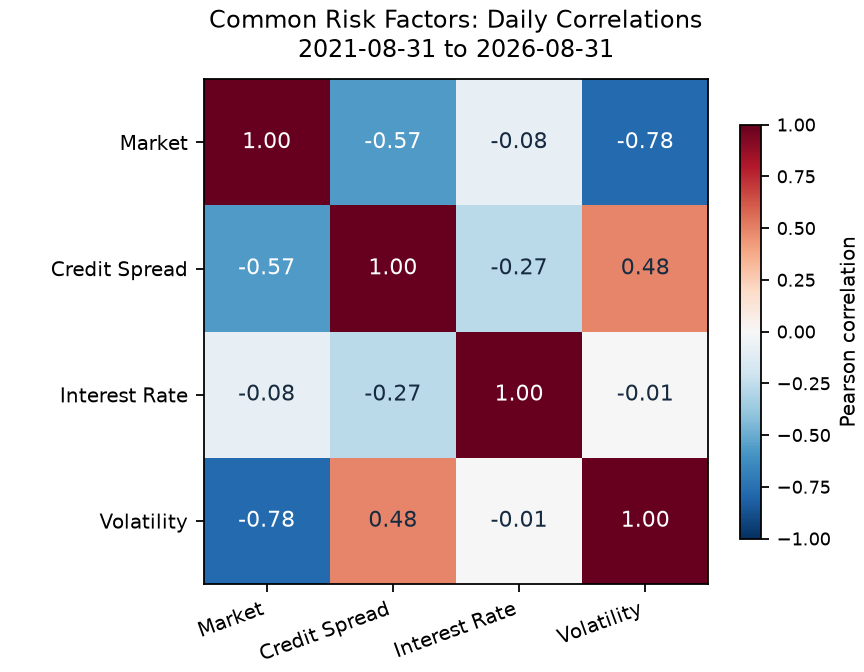

764

In [4]:
# 1. Factor correlation heatmap: inspect overlap among the regressors.
# These are factor correlations, not equity-SRT portfolio correlations.
factor_correlation = data[FACTORS].corr()
heat_labels = ["Market", "Credit Spread", "Interest Rate", "Volatility"]
fig, ax = plt.subplots(figsize=(5.4, 4.2), layout="constrained")
im = ax.imshow(factor_correlation.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(4), heat_labels, rotation=20, ha="right", fontsize=9)
ax.set_yticks(range(4), heat_labels, fontsize=9)
for i in range(4):
    for j in range(4):
        value = factor_correlation.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=10,
                color="white" if abs(value) > .55 else "#172b40")
ax.set_title("Common Risk Factors: Daily Correlations\n"
             f"{data.index.min():%Y-%m-%d} to {data.index.max():%Y-%m-%d}", pad=10, fontsize=11)
colorbar = fig.colorbar(im, ax=ax, shrink=.82)
colorbar.set_label("Pearson correlation", fontsize=9)
colorbar.ax.tick_params(labelsize=8)
heatmap_path = OUT / "factor_correlation_heatmap.png"
fig.savefig(heatmap_path, dpi=160, facecolor="white")
plt.close(fig)
display(Image(filename=str(heatmap_path), width=540))

# 2. Save numerical results and audits for Sections 6 and 8.
holdings.to_csv(OUT / "equity_holdings.csv", index=False)
data.to_csv(OUT / "equity_model_inputs.csv")
stock_returns.to_csv(OUT / "equity_stock_returns.csv", index_label="Date")
gap_audit.to_csv(OUT / "factor_gap_audit.csv", index_label="Date")
sources.to_csv(OUT / "source_metadata.csv", index=False)
regression.to_csv(OUT / "equity_regression.csv", index_label="Term")
beta_equity.to_csv(OUT / "equity_beta.csv")
factor_correlation.to_csv(OUT / "factor_correlation.csv")
vif.to_csv(OUT / "factor_vif.csv")
fit_stats.to_csv(OUT / "equity_fit_statistics.csv")
(OUT / "run_metadata.json").write_text(json.dumps({
    "requested_window": [START, END], "sample_start": str(data.index.min().date()),
    "sample_end": str(data.index.max().date()), "observations": len(data),
    "factor_order": FACTORS, "market_proxy": "Fama-French Mkt-RF", "risk_free": "Fama-French daily RF", "dependent_variable": "daily equal-weight excess return (total return minus French RF)",
    "rebalancing": "daily, no costs", "HAC_lags": 5, "inference": "t reference, residual degrees of freedom; HAC approximation",
    "factor_units": ["decimal return", "bp change", "bp change", "index point change"],
    "cache_dir": str(cache_dir), "offline": OFFLINE,
}, indent=2), encoding="utf-8")


## 5. SRT Buckets: Model-Based Factor Sensitivities

Use **three tranche levels × two pool qualities** to obtain six buckets, each with a **1 × 4 beta vector**. Reuse Case 2's credit-loss mechanics, then add explicit assumptions linking the four observable market factors to those mechanics and to valuation. The output is **24 assumption-based sensitivities**, not a regression fitted to SRT prices.

I reuse Case 2’s model mechanics and helper functions, supplemented by the AI-assisted assumptions below to connect them to the four observable factors.

**Calculation:** specify the two pools and three tranche boundaries → simulate loan losses → allocate losses to each tranche → discount remaining principal and coupons → repeat with positive/negative shocks to each factor → calculate four betas per bucket.

The function `estimate_bucket_betas` calculates:

$$
\beta_{b,k}=\frac{V_{b,k}^{+}-V_{b,k}^{-}}{2h_kV_{b,0}},
$$

where $V_{b,k}^{+}$ and $V_{b,k}^{-}$ are simulated values after a positive/negative factor shock, $h_k$ is the shock size, and $V_{b,0}$ is the baseline value. This finite-difference calculation produces every entry in the **6 × 4 matrix** below.

### SRT Portfolio Allocation

Assume 20 equal-sized positions of \$25MM each, with allocated capital equal to initial tranche model value at par. Each position is assigned to one bucket: first-loss 4/4, mezzanine 5/5 and senior 1/1 across higher-/lower-quality pools. These are case assumptions, not market allocation benchmarks.

<div style="overflow-x:auto; margin:12px 0;">
<table style="width:100%; border-collapse:collapse; font-size:12px; line-height:1.5; text-align:left;" cellpadding="8">
<thead><tr style="background:rgba(128,128,128,0.12); border-bottom:2px solid rgba(128,128,128,0.4);"><th>SRT Bucket</th><th>Positions</th><th>Allocated Capital</th><th>SRT Sleeve Weight</th></tr></thead>
<tbody>
<tr><td>First-loss / Higher quality</td><td>4</td><td>$100MM</td><td>20%</td></tr>
<tr><td>First-loss / Lower quality</td><td>4</td><td>$100MM</td><td>20%</td></tr>
<tr><td>Mezzanine / Higher quality</td><td>5</td><td>$125MM</td><td>25%</td></tr>
<tr><td>Mezzanine / Lower quality</td><td>5</td><td>$125MM</td><td>25%</td></tr>
<tr><td>Senior / Higher quality</td><td>1</td><td>$25MM</td><td>5%</td></tr>
<tr><td>Senior / Lower quality</td><td>1</td><td>$25MM</td><td>5%</td></tr>
<tr style="background:rgba(128,128,128,0.09); border-top:2px solid rgba(128,128,128,0.4); font-weight:600;"><td>Total</td><td>20</td><td>$500MM</td><td>100%</td></tr>
</tbody></table>
</div>

Aggregate SRT factor sensitivities using these sleeve weights: $\boldsymbol\beta_{SRT}=\sum_b w_b\boldsymbol\beta_b$. Mezzanine accounts for 50% of capital, first-loss 40% and senior 10%; higher- and lower-quality pools each account for 50%.


### AI-Driven Illustrative Assumptions

These assumptions were proposed by AI to generate the 24 model sensitivities by linking Case 2 to the four factors. The revised mappings are deliberately milder than the initial illustration; they are not calibrated to observed SRT prices.

- **Buckets:** illustrative tranche boundaries of 0–10%, 10–20% and 20–100%, rather than representative market SRT structures; annual WAPDs of 1% and 3%. Scale Case 2's borrower PDs to these WAPDs while retaining its sector mix. Replenishment maintains each pool's quality.
- **Market → macro:** −10% market excess return shifts the adverse macro state by +0.10, affecting both defaults and LGD.
- **Credit spread → credit and valuation:** +100 bp adds 0.10 to borrower PD log-odds and 25 bp to the required valuation premium.
- **Yield → financing and valuation:** reuse Case 2's +0.130 annual PD log-odds per +100 bp; also move the floating coupon base and discount rate with the benchmark yield.
- **VIX → dependence:** +10 VIX points increases the macro–LGD loading by 0.05.
- **Valuation setup:** five-year quarterly cash flows, 3% base rate and an added 1% required premium. Solve each bucket's coupon spread so its baseline model value equals par, then keep that spread fixed under shocks. This par-coupon construction is new; it replaces Case 2's fixed +700 bp coupon for this illustration.

Factor shocks are ±1% market excess return, ±10 bp credit spread, ±10 bp yield and ±1 VIX point. The code uses identical random streams across scenarios. These mappings and valuation choices are manual assumptions; Case 2 does not calibrate them. They determine the resulting beta magnitudes.

The rate mapping is retained from Case 2. Market, spread and VIX mappings are milder than the initial illustration; there is no forced ranking, clipping or direct scaling of the output beta matrix. The maturity is five years.


In [5]:
from dataclasses import asdict
from _LIB_case3 import SRTSettings, estimate_bucket_betas

# Editable illustrative inputs; boundaries are fractions of reference-pool face.
SRT_TRANCHES = {
    "First-loss": (0.00, 0.10),
    "Mezzanine": (0.10, 0.20),
    "Senior": (0.20, 1.00),
}
SRT_POOL_QUALITY = {"Higher": 0.01, "Lower": 0.03}  # Annual WAPD
SRT_SETTINGS = SRTSettings(
    paths=5000, seed=20261005,
    market_to_macro=-1.0,
    spread_to_pd_logodds=0.001,
    spread_to_required_premium=0.25,
    vix_to_lgd_loading=0.005,
    yield_pass_through=1.0,
)
SRT_BUMPS = (0.01, 10.0, 10.0, 1.0)  # Market return, spread bp, yield bp, VIX points


In [6]:
srt_buckets, srt_repricing = estimate_bucket_betas(
    SRT_TRANCHES, SRT_POOL_QUALITY, SRT_SETTINGS, SRT_BUMPS)
beta_srt = srt_buckets[FACTORS]
assert beta_srt.shape == (6, 4)
assert np.isfinite(beta_srt.to_numpy()).all()
np.testing.assert_allclose(srt_repricing.Baseline_price, 1.0)

# One row = one bucket's 1 × 4 beta vector, in equity factor order.
display(beta_srt.style.format({"Market": "{:.4f}", "Credit_Spread_bp": "{:.6f}",
                              "Interest_Rate_bp": "{:.6f}", "Volatility_pts": "{:.6f}"})
        .set_caption("SRT six-bucket betas — illustrative assumptions"))

SRT_OUT = OUT / "srt_illustrative"
SRT_OUT.mkdir(parents=True, exist_ok=True)
srt_buckets.to_csv(SRT_OUT / "bucket_inputs_and_betas.csv")
beta_srt.to_csv(SRT_OUT / "srt_beta_6x4.csv")
srt_repricing.to_csv(SRT_OUT / "factor_repricing.csv", index=False)
(SRT_OUT / "assumptions.json").write_text(json.dumps({
    "status": "AI-driven illustrative sensitivities; manually revised mappings; not market calibrated",
    "tranches": SRT_TRANCHES, "annual_WAPD": SRT_POOL_QUALITY,
    "settings": asdict(SRT_SETTINGS), "bumps": SRT_BUMPS,
    "factor_order": FACTORS, "normalization": "initial model value (par)",
    "LGD": "conditional mean; no independent Beta severity draws",
}, indent=2), encoding="utf-8")


,,Market,Credit_Spread_bp,Interest_Rate_bp,Volatility_pts
Seniority,Pool_quality,,,,
First-loss,Higher,0.4163,-0.000376,-0.000365,-0.000580
Mezzanine,Higher,0.0533,-0.000150,-0.000047,-0.000114
Senior,Higher,0.0007,-0.000113,-0.000001,-0.000002
First-loss,Lower,0.8294,-0.000668,-0.000778,-0.000949
Mezzanine,Lower,0.4078,-0.000403,-0.000377,-0.000725
Senior,Lower,0.0246,-0.000130,-0.000022,-0.000059


1034

## 6. Factor-Implied Correlations and Critical Assumptions

To address the question's **critical correlation assumptions**, use the same five-year factor sample as the equity regression. First calculate the **4 × 4 factor covariance matrix**, then combine it with the equity beta vector and each SRT bucket's beta vector to obtain **six equity–SRT correlations**.

$$
\Sigma_F=\operatorname{Cov}(\mathbf f_t),\qquad
\rho_{E,j}^{F}
=\frac{\boldsymbol\beta_E\Sigma_F\boldsymbol\beta_j^{\mathsf T}}
{\sqrt{(\boldsymbol\beta_E\Sigma_F\boldsymbol\beta_E^{\mathsf T})
        (\boldsymbol\beta_j\Sigma_F\boldsymbol\beta_j^{\mathsf T})}}.
$$

A positive correlation indicates that the two positions' **common-factor return components** tend to move together; a negative correlation indicates opposite movements. Applying the SRT valuation sensitivities to daily factors assumes that these sensitivities remain fixed; the resulting correlations are illustrative and exclude residual risk.


In [7]:
# Same dates and factor units as Section 4; no standardization or unit changes.
factor_covariance = data[FACTORS].cov()
sigma_f = factor_covariance.to_numpy()
np.testing.assert_allclose(sigma_f, sigma_f.T, atol=1e-12)
assert np.linalg.eigvalsh(sigma_f).min() >= -1e-10

factor_labels = {"Market": "Market (Mkt-RF)", "Credit_Spread_bp": "Credit Spread (bp)",
                 "Interest_Rate_bp": "Interest Rate (bp)", "Volatility_pts": "Volatility (pts)"}
display(factor_covariance.rename(index=factor_labels, columns=factor_labels)
        .style.format("{:.4e}").set_caption("Four-factor daily covariance matrix — same five-year sample"))
CORR_OUT = OUT / "correlation"
CORR_OUT.mkdir(parents=True, exist_ok=True)
factor_covariance.to_csv(CORR_OUT / "factor_covariance.csv")


,Market (Mkt-RF),Credit Spread (bp),Interest Rate (bp),Volatility (pts)
Market (Mkt-RF),1.2461e-04,-5.6665e-02,-5.5154e-03,-1.5441e-02
Credit Spread (bp),-5.6665e-02,7.9554e+01,-1.4834e+01,7.6861e+00
Interest Rate (bp),-5.5154e-03,-1.4834e+01,3.8508e+01,-8.0853e-02
Volatility (pts),-1.5441e-02,7.6861e+00,-8.0853e-02,3.1613e+00


In [8]:
bucket_order = pd.MultiIndex.from_product(
    [list(SRT_TRANCHES), ["Lower", "Higher"]], names=["Seniority", "Pool_quality"])
b_e = beta_equity[FACTORS].iloc[0].to_numpy()
b_s = beta_srt.reindex(bucket_order)[FACTORS].to_numpy()

cov_equity_srt = b_s @ sigma_f @ b_e
var_equity_factor = b_e @ sigma_f @ b_e
var_srt_factor = np.einsum("ij,jk,ik->i", b_s, sigma_f, b_s)
if var_equity_factor <= 0 or (var_srt_factor <= 0).any():
    raise ValueError("Correlation is undefined for a zero-variance factor component")
rho = cov_equity_srt / np.sqrt(var_equity_factor * var_srt_factor)
assert np.isfinite(rho).all() and (np.abs(rho) <= 1 + 1e-10).all()
implied_correlation = pd.DataFrame({"Equity_factor_correlation": rho}, index=bucket_order)

# Verify against correlations of the directly constructed factor-return series.
equity_factor_returns = data[FACTORS].to_numpy() @ b_e
srt_factor_returns = data[FACTORS].to_numpy() @ b_s.T
np.testing.assert_allclose(
    rho, np.corrcoef(np.column_stack([equity_factor_returns, srt_factor_returns]), rowvar=False)[0, 1:],
    atol=1e-12)

display(implied_correlation.rename(columns={"Equity_factor_correlation": "Correlation with Equity"})
        .style.format("{:+.3f}").set_caption("Equity–SRT factor-implied correlations"))
implied_correlation.to_csv(CORR_OUT / "equity_srt_implied_correlation.csv")


### Observations

- All six buckets have **positive** factor-implied correlation with equity, ranging from approximately **0.59 to 0.95** under the current SRT assumptions.
- First-loss buckets have correlations near **0.95**, indicating substantial common-factor overlap with equity. Senior buckets show lower correlations (**0.59** for higher-quality and **0.76** for lower-quality pools).
- The long equity sleeve and protection-selling SRT buckets therefore do not provide opposite common-factor exposures in this illustration. 


## 7. Proposed Hedge Tools

Use the following instruments to offset the current long book's four common-factor exposures.

<div style="overflow-x:auto; margin:12px 0 16px;">
<table style="width:100%; border-collapse:collapse; font-size:12px; line-height:1.5; text-align:left;">
<thead><tr style="background:rgba(128,128,128,0.12); border-bottom:2px solid rgba(128,128,128,0.4);"><th style="width:18%; padding:9px 12px; text-align:left; font-size:12px;">Common Factor</th><th style="width:29%; padding:9px 12px; text-align:left; font-size:12px;">Hedge Tool</th><th style="padding:9px 12px; text-align:left; font-size:12px;">Position Direction and Purpose</th></tr></thead>
<tbody>
<tr style="border-bottom:1px solid rgba(128,128,128,0.25);"><td style="padding:9px 12px; vertical-align:top; font-size:12px;"><strong>1. Market</strong></td><td style="padding:9px 12px; vertical-align:top; font-size:12px;">E-mini S&amp;P 500 futures (ES)</td><td style="padding:9px 12px; vertical-align:top; font-size:12px;"><strong>Short futures</strong> to offset equity and SRT losses when the broad market falls.</td></tr>
<tr style="border-bottom:1px solid rgba(128,128,128,0.25);"><td style="padding:9px 12px; vertical-align:top; font-size:12px;"><strong>2. Credit Spread</strong></td><td style="padding:9px 12px; vertical-align:top; font-size:12px;">5-year CDX.NA.HY / CDX.NA.IG</td><td style="padding:9px 12px; vertical-align:top; font-size:12px;"><strong>Buy protection</strong> to offset losses from spread widening; match the index to the underlying pools.</td></tr>
<tr style="border-bottom:1px solid rgba(128,128,128,0.25);"><td style="padding:9px 12px; vertical-align:top; font-size:12px;"><strong>3. Interest Rate</strong></td><td style="padding:9px 12px; vertical-align:top; font-size:12px;">10-year Treasury futures (ZN)</td><td style="padding:9px 12px; vertical-align:top; font-size:12px;"><strong>Short futures</strong> to offset the portfolio's negative sensitivity to rising yields.</td></tr>
<tr style="border-bottom:1px solid rgba(128,128,128,0.25);"><td style="padding:9px 12px; vertical-align:top; font-size:12px;"><strong>4. Volatility</strong></td><td style="padding:9px 12px; vertical-align:top; font-size:12px;">VIX futures (VX)</td><td style="padding:9px 12px; vertical-align:top; font-size:12px;"><strong>Long futures</strong> to offset negative volatility exposure when the relevant futures price rises.</td></tr>
</tbody></table>
</div>

Sources: [CME: equity beta hedging](https://www.cmegroup.com/education/whitepapers/hedging-with-e-mini-sp-500-future), [S&P: CDX indices](https://www.spglobal.com/spdji/en/indices/products/markit-cdx.html), [CME: Treasury DV01 hedging](https://www.cmegroup.com/trading/interest-rates/calculating-the-dollar-value-of-a-basis-point.html), [Cboe: VIX futures](https://www.cboe.com/tradable-products/vix/vix-futures/).


## 8. Portfolio Presentation Table

Combine the saved Section 4 equity betas and Section 5 SRT betas with the selected allocations. Each exposure is signed dollar P&L for the stated shock, holding other factors fixed. Hedge contribution = unit sensitivity × position size.

### Illustrative Hedge Inputs

Hedge sensitivities below are explicit case assumptions. Contract multipliers are product specifications; quote-dependent values and factor mappings are not market estimates. All off-diagonal hedge sensitivities are assumed zero.

<div style="overflow-x:auto; margin:12px 0;"><table style="width:100%; border-collapse:collapse; font-size:11px; line-height:1.5;" cellpadding="8">
<thead><tr style="background:rgba(128,128,128,0.12);"><th>Hedge / Unit</th><th>Assumed Inputs</th><th>Signed Unit Sensitivity</th></tr></thead>
<tbody>
<tr><td>Short ES / 1 contract</td><td>Assumed price 5,000 × $50 multiplier; market mapping 1</td><td>−$2,500 / +1% market</td></tr>
<tr><td>Buy 5Y CDX.NA.HY protection / $1MM notional</td><td>Assumed CS01 $400; CDX spread / HY OAS mapping 1</td><td>+$400 / +1 bp HY OAS</td></tr>
<tr><td>Short ZN / 1 contract</td><td>Assumed DV01 $75; benchmark-yield mapping 1</td><td>+$75 / +1 bp benchmark yield</td></tr>
<tr><td>Long VX / 1 contract</td><td>$1,000 multiplier; assumed +0.6 futures points / +1 spot-VIX point</td><td>+$600 / +1 VIX point</td></tr>
</tbody></table></div>

Multipliers: [CME ES](https://www.cmegroup.com/education/whitepapers/hedging-with-e-mini-sp-500-future), [Cboe VX](https://cdn.cboe.com/resources/membership/Options_on_VX_Futures_Whitepaper.pdf).

Size each hedge to offset its factor's long-book exposure, then round futures to whole contracts and CDX notional to the nearest $0.1MM. SRT capital is assumed equal to initial tranche model value. Near-zero net exposure is conditional on these simplified linear assumptions; it does not establish a market-calibrated hedge. Premiums, carry, transaction costs, margin funding and nonlinear risks are excluded. The equity VIX coefficient is not statistically significant.

### Long Book, Hedge Book and Net Exposures


In [9]:
from scripts.case3_hedge_table import build_presentation

# Uses the saved beta exports from Sections 4 and 5 and explicit hedge assumptions.
presentation_html, presentation_rows = build_presentation(ROOT)
display(HTML(presentation_html))


Position,Size,Market$/+1%,Credit Spread$/+1 bp,Interest Rate$/+1 bp,Volatility$/+1 VIX point
Equity portfolio,$500MM; 20 stocks,"+$3,473,890","−$19,765","−$33,144","−$24,696"
SRT portfolio,$500MM; 20 positions,"+$1,828,456","−$179,593","−$167,855","−$259,291"
Long book total,$1B allocated capital,"+$5,302,346","−$199,358","−$200,999","−$283,987"
Short ES,"2,121 contracts","−$5,302,500",$0,$0,$0
Buy CDX.NA.HY protection,$498.4MM notional; 5Y,$0,"+$199,360",$0,$0
Short ZN,"2,680 contracts",$0,$0,"+$201,000",$0
Long VX,473 contracts,$0,$0,$0,"+$283,800"
Hedge book total,Illustrative hedge positions,"−$5,302,500","+$199,360","+$201,000","+$283,800"
Net exposures,Long book + hedge book,−$154,+$2,+$1,−$187


## 9. Discuss Critical Correlation Assumptions and Stress Scenarios

In this exercise, I do not explicitly specify a correlation coefficient between the equity and SRT portfolios. Instead, the equity–SRT correlation table in Section 6 shows the common-factor correlations implied by the derived sensitivities and historical factor covariance. These results are illustrative rather than validated estimates of actual portfolio correlations: dependence is implicitly embedded in the shared-factor structure, the SRT parameter assumptions and the sensitivity mappings.

Stress scenarios have not been executed in this exercise. A proposed test is a severe joint shock in which the market falls, interest rates rise, credit spreads widen and volatility increases, while hedge effectiveness weakens. For example, HY OAS could widen by 100 bp while CDX spreads respond less than the assumed one-to-one mapping. With hedge sizes held fixed, incomplete offsets could leave large residual factor exposures and substantial portfolio losses despite the near-zero net exposures in the initial linear model.



## 10. AI Usage Summary

1. **Framework development through dialogue:** I developed the framework through ongoing conversations with ChatGPT. At each step, I shared my ideas, ChatGPT proposed alternatives or corrected my understanding, and I challenged or revised its suggestions. The final framework reflects this iterative exchange.
2. **Factor selection and SRT illustration:** I initially selected the four common factors. AI helped link these factors to SRT risk through illustrative modeling assumptions and generated the simulated sensitivity estimates. These numbers are illustrative, not calibrated to observed SRT market prices.
3. **Code development and review:** Most of the code was written by AI. I asked it to reuse Case 2's existing helper functions where possible to simulate SRT outcomes and estimate the factor sensitivities (betas). Given the time constraints and my limited familiarity with this context, my review focused on the overall approach rather than a detailed examination of the simulation implementation.
4. **Hedge tools and exposure calculations:** AI explained the hedge instruments, trade directions and exposure calculations, and guided me through the unit-sensitivity assumptions, position sizing and calculation of net exposures. The resulting hedge book is an illustrative proposal.
